<a href="https://colab.research.google.com/github/oumlk/french-wino-what/blob/main/WinoQuoi_Experiment_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# French WinoWhat Replication
## Model Evaluation on Original and Paraphrased French Winograd Data

This notebook replicates the WinoWhat framework (Gevers et al., 2025) in French using a combined dataset of 200 instances drawn from two sources:

- **French Winograd Schemas** (Amsili and Seminck, 2017): 100 instances parsed from the original XML file. These are Google-proof French Winograd schemas designed for commonsense coreference resolution.
- **WinoWhat validation subset translated into French** (Gevers et al., 2025): 100 instances from the English WinoWhat dataset, translated using the DeepL API.

### Dataset structure

The original French Winograd schemas use pronoun-based coreference sentences. To align with the WinoWhat framework, which uses a fill-in-the-blank token (`_`), each sentence was converted: the ambiguous pronoun was replaced by `_`, and the two candidate antecedents became `option1` and `option2`. The translated WinoWhat instances already follow this format.

### Paraphrases

Each sentence was manually paraphrased to produce a meaning-preserving variant in which the `_` token appears at the end of the sentence. This mirrors the WinoWhat corpus design and removes the positional dependency of the partial evaluation metric. All paraphrases were checked for grammaticality and preservation of ambiguity.

### Evaluation methods

Three models are evaluated across two scoring protocols:

- **Mistral-7B (Causal LM): Partial evaluation.** Scoring follows the implementation of Gevers et al. (2025) (`run_llm.py`). The summed log-likelihood of the option tokens is computed given the sentence prefix, using `tokenizer.encode` with `add_special_tokens=False` and `torch.gather` on the shifted logits.
- **CamemBERT-base (Masked LM): Pseudo-log-likelihood (PLL).** French-specific encoder. Each completed sentence is scored by masking one token at a time and summing log P(token | rest of sentence).
- **XLM-RoBERTa-base (Masked LM): Pseudo-log-likelihood (PLL).** Multilingual encoder trained on 100 languages including French. Same scoring protocol as CamemBERT, allowing direct comparison between a French-specific and a multilingual masked LM.

### Statistical reporting

Confidence intervals use the Wilson score interval. Significance of the original vs. paraphrase drop is assessed with McNemar's exact test (paired binary predictions). Effect size is reported as |b - c| / (b + c) (Cohen's g). Between-model comparisons use the same test following Gevers et al. (2025).

In [1]:
# Install required libraries
!pip -q install transformers==4.44.0 tokenizers==0.19.1 accelerate sentencepiece pandas tqdm statsmodels --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 54.1 MB/s eta 0:00:00


In [2]:
import os
import math
import random
import numpy as np
import pandas as pd
import torch
import shutil

from tqdm.auto import tqdm
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForMaskedLM,
    CamembertTokenizer,
    CamembertForMaskedLM,
    XLMRobertaTokenizer,
    XLMRobertaForMaskedLM
)
from google.colab import drive, files

# Reproducibility seeds match Gevers et al. (2025) run_llm.py
random.seed(0)
np.random.seed(1234)
torch.manual_seed(1234)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(1234)

In [3]:
# Verify library versions
# transformers==4.44.0 and tokenizers==0.19.1 are required
# to avoid the CamemBERT tokenizer PyTuple bug in newer versions
import transformers, tokenizers
print("transformers:", transformers.__version__)
print("tokenizers  :", tokenizers.__version__)

transformers: 4.44.0
tokenizers  : 0.19.1


In [4]:
drive.mount('/content/drive')

csv_path = "/content/drive/MyDrive/Thesis_2025/new/french_wino_with_paraphrases.csv"
df = pd.read_csv(csv_path)

print("Raw rows:", len(df))
print(df.head())

Mounted at /content/drive
Raw rows: 200
   id                                           sentence  \
0   1  La coupe n'entre pas dans la valise marron, ca...   
1   2  Paul a essayé de joindre Georges sur son télép...   
2   3  L'avocat a posé une question au témoin, mais _...   
3   4  Nicolas n'a pas pu soulever son fils car _ éta...   
4   5  Les lycéens harcelaient les collégiens, donc o...   

                                paraphrased_sentence         option1  \
0  Impossible de faire entrer la coupe dans la va...       la valise   
1  Paul a tenté d'appeler Georges sur son portabl...            Paul   
2  L'avocat a posé une question au témoin ; ce de...        l'avocat   
3  Comme _ était trop faible, Nicolas n’a pas réu...         Nicolas   
4  À cause du harcèlement envers les collégiens, ...  les collégiens   

       option2  answer  
0     la coupe       2  
1      Georges       1  
2    le témoin       1  
3     son fils       1  
4  les lycéens       2  


## 1. Dataset Statistics

Descriptive statistics of the dataset before evaluation.

In [5]:
# Instance counts and label distribution
print(f"Total instances          : {len(df)}")
print(f"Instances with answer=1  : {(df['answer'] == 1).sum()} ({(df['answer'] == 1).mean()*100:.1f}%)")
print(f"Instances with answer=2  : {(df['answer'] == 2).sum()} ({(df['answer'] == 2).mean()*100:.1f}%)")
print()

# Sentence length in words (whitespace split approximation)
df["orig_len"] = df["sentence"].apply(lambda x: len(str(x).split()))
df["para_len"] = df["paraphrased_sentence"].apply(lambda x: len(str(x).split()))

print("Original sentence length (words):")
print(f"  Mean: {df['orig_len'].mean():.1f}  Std: {df['orig_len'].std():.1f}  Min: {df['orig_len'].min()}  Max: {df['orig_len'].max()}")
print("Paraphrased sentence length (words):")
print(f"  Mean: {df['para_len'].mean():.1f}  Std: {df['para_len'].std():.1f}  Min: {df['para_len'].min()}  Max: {df['para_len'].max()}")
print()

# Option lengths
df["opt1_len"] = df["option1"].apply(lambda x: len(str(x).split()))
df["opt2_len"] = df["option2"].apply(lambda x: len(str(x).split()))
print(f"Option 1 length (words): Mean {df['opt1_len'].mean():.2f}")
print(f"Option 2 length (words): Mean {df['opt2_len'].mean():.2f}")
print()

# Blank format validation
bad_orig = (df["sentence"].str.count("_") != 1).sum()
bad_para = (df["paraphrased_sentence"].str.count("_") != 1).sum()
print(f"Sentences with != 1 blank (original)    : {bad_orig}")
print(f"Sentences with != 1 blank (paraphrased) : {bad_para}")

# Blank position: paraphrased sentences should have blank near the end
def blank_position_ratio(text):
    words = str(text).split()
    if "_" not in words:
        return None
    return words.index("_") / max(len(words) - 1, 1)

df["orig_blank_pos"] = df["sentence"].apply(blank_position_ratio)
df["para_blank_pos"] = df["paraphrased_sentence"].apply(blank_position_ratio)

print()
print(f"Blank position (original)    : Mean={df['orig_blank_pos'].mean():.2f} (0=start, 1=end)")
print(f"Blank position (paraphrased) : Mean={df['para_blank_pos'].mean():.2f} (should be closer to 1)")

# Example instances
print()
print("EXAMPLE INSTANCES")
for _, row in df.head(3).iterrows():
    print(f"  ID {row['id']}")
    print(f"    Original    : {row['sentence']}")
    print(f"    Paraphrased : {row['paraphrased_sentence']}")
    print(f"    Option 1: {row['option1']}  |  Option 2: {row['option2']}  |  Answer: {row['answer']}")
    print()

Total instances          : 200
Instances with answer=1  : 92 (46.0%)
Instances with answer=2  : 108 (54.0%)

Original sentence length (words):
  Mean: 18.8  Std: 5.0  Min: 9  Max: 34
Paraphrased sentence length (words):
  Mean: 20.3  Std: 5.6  Min: 8  Max: 45

Option 1 length (words): Mean 1.48
Option 2 length (words): Mean 1.49

Sentences with != 1 blank (original)    : 0
Sentences with != 1 blank (paraphrased) : 0

Blank position (original)    : Mean=0.74 (0=start, 1=end)
Blank position (paraphrased) : Mean=0.70 (should be closer to 1)

EXAMPLE INSTANCES
  ID 1
    Original    : La coupe n'entre pas dans la valise marron, car _ est trop grande.
    Paraphrased : Impossible de faire entrer la coupe dans la valise marron puisque _ est trop grande.
    Option 1: la valise  |  Option 2: la coupe  |  Answer: 2

  ID 2
    Original    : Paul a essayé de joindre Georges sur son téléphone, mais _ n'a pas réussi.
    Paraphrased : Paul a tenté d'appeler Georges sur son portable, cependant _ n

In [6]:
# Clean and validate data
required_cols = ["id", "sentence", "paraphrased_sentence", "option1", "option2", "answer"]
df = df.dropna(subset=required_cols).copy()

for col in ["sentence", "paraphrased_sentence", "option1", "option2"]:
    df[col] = df[col].astype(str).str.strip()

df["answer"] = df["answer"].astype(int)

print("After cleaning:", len(df))
print("Answer distribution:")
print(df["answer"].value_counts())

bad_original = (df["sentence"].str.count("_") != 1).sum()
bad_para     = (df["paraphrased_sentence"].str.count("_") != 1).sum()
print(f"\nBad original rows  : {bad_original}")
print(f"Bad paraphrase rows: {bad_para}")

if bad_original > 0 or bad_para > 0:
    print("Dropping malformed rows...")
    df = df[(df["sentence"].str.count("_") == 1) &
            (df["paraphrased_sentence"].str.count("_") == 1)].copy()
    print(f"Rows remaining: {len(df)}")

After cleaning: 200
Answer distribution:
answer
2    108
1     92
Name: count, dtype: int64

Bad original rows  : 0
Bad paraphrase rows: 0


## 2. Helper Functions

In [7]:
def fill_blank(text, option):
    """Replace the blank token with a candidate option."""
    return text.replace("_", option)


def wilson_ci(acc, n, z=1.96):
    """
    Wilson score confidence interval for a proportion.
    More reliable than the normal approximation for moderate n,
    especially when accuracy is near 0 or 1.
    Returns (lower, upper).
    """
    if n == 0:
        return (0.0, 1.0)
    denominator = 1 + z**2 / n
    centre = (acc + z**2 / (2 * n)) / denominator
    margin = (z / denominator) * math.sqrt(acc * (1 - acc) / n + z**2 / (4 * n**2))
    return (max(0.0, centre - margin), min(1.0, centre + margin))

## 3. Scoring Classes

Three scorers are defined, one per model type.

In [8]:
# Causal LM scorer for Mistral-7B
# Uses partial evaluation: summed log-likelihood of the option tokens
# given the sentence prefix (everything before the blank).
# Implementation follows Gevers et al. (2025) run_llm.py exactly:
#   - tokenizer.encode with add_special_tokens=False (True only for Gemma)
#   - continuation_ids sliced from full encoding minus context encoding
#   - log-probs extracted with torch.gather on shifted logits
#   - evaluate_on_full_continuation=False scores option tokens only

class CausalPartialScorer:
    def __init__(self, model_name):
        self.model_is_gemma = "gemma" in model_name.lower()
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name,
            revision="main",
            torch_dtype="auto",
            trust_remote_code=False,
            device_map="auto"
        )
        self.model.eval()
        self.model.tie_weights()
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            revision="main",
            trust_remote_code=False,
            device_map="auto"
        )

    @torch.no_grad()
    def score_option(self, sentence_with_blank, option,
                     evaluate_on_full_continuation=False):
        add_special = self.model_is_gemma

        parts  = sentence_with_blank.split("_", 1)
        prefix = parts[0]
        suffix = parts[1].strip() if len(parts) > 1 else ""

        continuation = (option + " " + suffix).strip() if (suffix and evaluate_on_full_continuation) else option

        full_ids    = self.tokenizer.encode(prefix + continuation, add_special_tokens=add_special)
        context_ids = self.tokenizer.encode(prefix, add_special_tokens=add_special)
        continuation_ids = full_ids[len(context_ids):]

        if not continuation_ids:
            return float("-inf")

        max_length = 4096
        inp = torch.tensor(
            (context_ids + continuation_ids)[-(max_length + 1):][:-1],
            dtype=torch.long,
            device=self.model.device
        )
        (inplen,) = inp.shape

        logits    = self.model(inp.unsqueeze(0)).logits.squeeze(0).to(torch.float32)
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

        contlen   = len(continuation_ids)
        ctx_len   = inplen + (log_probs.shape[0] - inplen)
        lp_cont   = log_probs[ctx_len - contlen : ctx_len]
        cont_toks = torch.tensor(continuation_ids, device=self.model.device)
        selected  = torch.gather(
            lp_cont.unsqueeze(0), 2,
            cont_toks.unsqueeze(-1).unsqueeze(0)
        ).squeeze(-1)

        return float(selected.sum())

In [9]:
# Masked LM scorer for CamemBERT
# Uses pseudo-log-likelihood (PLL): each token is masked in turn
# and log P(token | rest of sentence) is summed across all non-special tokens.
# CamembertTokenizer with use_fast=False avoids a PyTuple conversion bug
# present in newer versions of the tokenizers library.
# Uses camembert/camembert-base (full HuggingFace path) to ensure
# the lm_head decoder weights load correctly.

class MaskedLMScorer:
    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.tokenizer = CamembertTokenizer.from_pretrained(
            model_name,
            use_fast=False
        )
        self.model = CamembertForMaskedLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

        # Verify lm_head weights are trained and not randomly initialised
        lm_head_weight = self.model.lm_head.decoder.weight
        print(f"  lm_head.decoder.weight shape : {lm_head_weight.shape}")
        print(f"  lm_head.decoder.weight mean  : {lm_head_weight.mean():.6f}")
        print(f"  lm_head.decoder.weight std   : {lm_head_weight.std():.6f}")
        print("  Expected std around 0.01 to 0.12 if weights loaded correctly.")
        print("  If std is close to 1.0 the weights are random and scores will be noise.")

    @torch.no_grad()
    def score(self, text):
        enc = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        input_ids      = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)
        seq_len        = input_ids.size(1)
        total_log_prob = 0.0

        for i in range(1, seq_len - 1):  # skip [CLS] and [SEP]
            masked_ids       = input_ids.clone()
            masked_ids[0, i] = self.tokenizer.mask_token_id
            outputs   = self.model(masked_ids, attention_mask=attention_mask)
            log_probs = torch.nn.functional.log_softmax(outputs.logits[0, i], dim=-1)
            total_log_prob += log_probs[input_ids[0, i]].item()

        return total_log_prob

In [10]:
# Masked LM scorer for XLM-RoBERTa
# Same pseudo-log-likelihood protocol as CamemBERT.
# XLM-RoBERTa is a multilingual masked LM trained on 100 languages
# including French. Comparing it with CamemBERT allows us to examine
# whether French-specific pretraining matters for this task.

class XLMRobertaScorer:
    def __init__(self, model_name):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)
        self.model = XLMRobertaForMaskedLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

        # Verify lm_head weights are trained and not randomly initialised
        lm_head_weight = self.model.lm_head.decoder.weight
        print(f"  lm_head.decoder.weight shape : {lm_head_weight.shape}")
        print(f"  lm_head.decoder.weight mean  : {lm_head_weight.mean():.6f}")
        print(f"  lm_head.decoder.weight std   : {lm_head_weight.std():.6f}")
        print("  Expected std around 0.01 to 0.12 if weights loaded correctly.")

    @torch.no_grad()
    def score(self, text):
        enc = self.tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
        input_ids      = enc["input_ids"].to(self.device)
        attention_mask = enc["attention_mask"].to(self.device)
        seq_len        = input_ids.size(1)
        total_log_prob = 0.0

        for i in range(1, seq_len - 1):  # skip [CLS] and [SEP]
            masked_ids       = input_ids.clone()
            masked_ids[0, i] = self.tokenizer.mask_token_id
            outputs   = self.model(masked_ids, attention_mask=attention_mask)
            log_probs = torch.nn.functional.log_softmax(outputs.logits[0, i], dim=-1)
            total_log_prob += log_probs[input_ids[0, i]].item()

        return total_log_prob

## 4. Evaluation Functions

In [11]:
def evaluate_causal(df, text_column, scorer):
    """
    Evaluate a causal LM on all instances in df[text_column].
    For each instance, scores both options and picks the higher one.
    Returns (accuracy, result_dataframe).
    """
    data = df.copy()
    predictions, score1_list, score2_list = [], [], []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"Causal [{text_column}]"):
        s1 = scorer.score_option(row[text_column], row["option1"])
        s2 = scorer.score_option(row[text_column], row["option2"])
        pred = 1 if s1 > s2 else 2
        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"]    = predictions
    data["score1"]  = score1_list
    data["score2"]  = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)
    return data["correct"].mean(), data


def evaluate_mlm(df, text_column, scorer):
    """
    Evaluate a masked LM on all instances in df[text_column].
    Uses pseudo-log-likelihood: fills blank with each option and scores
    the completed sentence. Returns (accuracy, result_dataframe).
    """
    data = df.copy()
    predictions, score1_list, score2_list = [], [], []

    for _, row in tqdm(data.iterrows(), total=len(data), desc=f"MLM [{text_column}]"):
        s1 = scorer.score(fill_blank(row[text_column], row["option1"]))
        s2 = scorer.score(fill_blank(row[text_column], row["option2"]))
        pred = 1 if s1 > s2 else 2
        predictions.append(pred)
        score1_list.append(s1)
        score2_list.append(s2)

    data["pred"]    = predictions
    data["score1"]  = score1_list
    data["score2"]  = score2_list
    data["correct"] = (data["pred"] == data["answer"]).astype(int)
    return data["correct"].mean(), data

## 5. Baselines and Output Setup

In [12]:
# Baselines
random_baseline      = 0.50
always_option1_baseline = (df["answer"] == 1).mean()

print("Baselines")
print(f"  Random (chance)  : {random_baseline:.4f}")
print(f"  Always option 1  : {always_option1_baseline:.4f}")
print(f"  (answer=1: {(df['answer']==1).sum()}/{len(df)}, answer=2: {(df['answer']==2).sum()}/{len(df)})")

# Output folder for results and figures
output_dir = "/content/wino_results"
os.makedirs(output_dir, exist_ok=True)

# summary_rows accumulates one dict per model for the final summary table
summary_rows = []

Baselines
  Random (chance)  : 0.5000
  Always option 1  : 0.4600
  (answer=1: 92/200, answer=2: 108/200)


## 6. Mistral-7B  (Causal LM, Partial Evaluation)

In [13]:
print("Running Mistral-7B...")
mistral_model_name = "mistralai/Mistral-7B-v0.1"
mistral_scorer     = CausalPartialScorer(mistral_model_name)

orig_acc_mistral, orig_results_mistral = evaluate_causal(df, "sentence", mistral_scorer)
para_acc_mistral, para_results_mistral = evaluate_causal(df, "paraphrased_sentence", mistral_scorer)

orig_ci_mistral = wilson_ci(orig_acc_mistral, len(df))
para_ci_mistral = wilson_ci(para_acc_mistral, len(df))
drop_mistral    = orig_acc_mistral - para_acc_mistral

print(f"Original    : {orig_acc_mistral:.4f}  95% CI [{orig_ci_mistral[0]:.4f}, {orig_ci_mistral[1]:.4f}]")
print(f"Paraphrased : {para_acc_mistral:.4f}  95% CI [{para_ci_mistral[0]:.4f}, {para_ci_mistral[1]:.4f}]")
print(f"Drop        : {drop_mistral:.4f}")

# Save per-instance results and error files
orig_results_mistral.to_csv(os.path.join(output_dir, "results_original_mistral.csv"), index=False)
para_results_mistral.to_csv(os.path.join(output_dir, "results_paraphrased_mistral.csv"), index=False)
orig_results_mistral[orig_results_mistral["correct"] == 0].to_csv(
    os.path.join(output_dir, "wrong_original_mistral.csv"), index=False)
para_results_mistral[para_results_mistral["correct"] == 0].to_csv(
    os.path.join(output_dir, "wrong_paraphrased_mistral.csv"), index=False)

summary_rows.append({
    "model": "Mistral-7B", "scorer": "Causal (partial)",
    "orig_acc": orig_acc_mistral, "orig_ci_low": orig_ci_mistral[0], "orig_ci_high": orig_ci_mistral[1],
    "para_acc": para_acc_mistral, "para_ci_low": para_ci_mistral[0], "para_ci_high": para_ci_mistral[1],
    "drop": drop_mistral
})

Running Mistral-7B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.94G [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Causal [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


Causal [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original    : 0.4800  95% CI [0.4118, 0.5490]
Paraphrased : 0.5100  95% CI [0.4412, 0.5784]
Drop        : -0.0300


In [14]:
# Free GPU memory before loading the next model
del mistral_scorer
torch.cuda.empty_cache()

## 7. CamemBERT-base  (French Masked LM, Pseudo-Log-Likelihood)

In [15]:
print("Running CamemBERT...")
camembert_model_name = "camembert/camembert-base"
camembert_scorer     = MaskedLMScorer(camembert_model_name)

orig_acc_camembert, orig_results_camembert = evaluate_mlm(df, "sentence", camembert_scorer)
para_acc_camembert, para_results_camembert = evaluate_mlm(df, "paraphrased_sentence", camembert_scorer)

orig_ci_camembert = wilson_ci(orig_acc_camembert, len(df))
para_ci_camembert = wilson_ci(para_acc_camembert, len(df))
drop_camembert    = orig_acc_camembert - para_acc_camembert

print(f"Original    : {orig_acc_camembert:.4f}  95% CI [{orig_ci_camembert[0]:.4f}, {orig_ci_camembert[1]:.4f}]")
print(f"Paraphrased : {para_acc_camembert:.4f}  95% CI [{para_ci_camembert[0]:.4f}, {para_ci_camembert[1]:.4f}]")
print(f"Drop        : {drop_camembert:.4f}")

orig_results_camembert.to_csv(os.path.join(output_dir, "results_original_camembert.csv"), index=False)
para_results_camembert.to_csv(os.path.join(output_dir, "results_paraphrased_camembert.csv"), index=False)
orig_results_camembert[orig_results_camembert["correct"] == 0].to_csv(
    os.path.join(output_dir, "wrong_original_camembert.csv"), index=False)
para_results_camembert[para_results_camembert["correct"] == 0].to_csv(
    os.path.join(output_dir, "wrong_paraphrased_camembert.csv"), index=False)

summary_rows.append({
    "model": "CamemBERT-base", "scorer": "Masked (PLL)",
    "orig_acc": orig_acc_camembert, "orig_ci_low": orig_ci_camembert[0], "orig_ci_high": orig_ci_camembert[1],
    "para_acc": para_acc_camembert, "para_ci_low": para_ci_camembert[0], "para_ci_high": para_ci_camembert[1],
    "drop": drop_camembert
})

Running CamemBERT...


sentencepiece.bpe.model:   0%|          | 0.00/811k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/509 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of the model checkpoint at camembert/camembert-base were not used when initializing CamembertForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing CamembertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing CamembertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


  lm_head.decoder.weight shape : torch.Size([32005, 768])
  lm_head.decoder.weight mean  : -0.025573
  lm_head.decoder.weight std   : 0.118624
  Expected std around 0.01 to 0.12 if weights loaded correctly.
  If std is close to 1.0 the weights are random and scores will be noise.


MLM [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

MLM [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original    : 0.4650  95% CI [0.3972, 0.5341]
Paraphrased : 0.4700  95% CI [0.4020, 0.5391]
Drop        : -0.0050


In [16]:
# Free GPU memory before loading XLM-RoBERTa
del camembert_scorer
torch.cuda.empty_cache()

## 8. XLM-RoBERTa-base  (Multilingual Masked LM, Pseudo-Log-Likelihood)

In [17]:
print("Running XLM-RoBERTa...")
xlmr_model_name = "xlm-roberta-base"
xlmr_scorer     = XLMRobertaScorer(xlmr_model_name)

orig_acc_xlmr, orig_results_xlmr = evaluate_mlm(df, "sentence", xlmr_scorer)
para_acc_xlmr, para_results_xlmr = evaluate_mlm(df, "paraphrased_sentence", xlmr_scorer)

orig_ci_xlmr = wilson_ci(orig_acc_xlmr, len(df))
para_ci_xlmr = wilson_ci(para_acc_xlmr, len(df))
drop_xlmr    = orig_acc_xlmr - para_acc_xlmr

print(f"Original    : {orig_acc_xlmr:.4f}  95% CI [{orig_ci_xlmr[0]:.4f}, {orig_ci_xlmr[1]:.4f}]")
print(f"Paraphrased : {para_acc_xlmr:.4f}  95% CI [{para_ci_xlmr[0]:.4f}, {para_ci_xlmr[1]:.4f}]")
print(f"Drop        : {drop_xlmr:.4f}")

orig_results_xlmr.to_csv(os.path.join(output_dir, "results_original_xlmr.csv"), index=False)
para_results_xlmr.to_csv(os.path.join(output_dir, "results_paraphrased_xlmr.csv"), index=False)
orig_results_xlmr[orig_results_xlmr["correct"] == 0].to_csv(
    os.path.join(output_dir, "wrong_original_xlmr.csv"), index=False)
para_results_xlmr[para_results_xlmr["correct"] == 0].to_csv(
    os.path.join(output_dir, "wrong_paraphrased_xlmr.csv"), index=False)

summary_rows.append({
    "model": "XLM-RoBERTa-base", "scorer": "Masked (PLL)",
    "orig_acc": orig_acc_xlmr, "orig_ci_low": orig_ci_xlmr[0], "orig_ci_high": orig_ci_xlmr[1],
    "para_acc": para_acc_xlmr, "para_ci_low": para_ci_xlmr[0], "para_ci_high": para_ci_xlmr[1],
    "drop": drop_xlmr
})

Running XLM-RoBERTa...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

...

Some weights of the model checkpoint at xlm-roberta-base were not used when initializing XLMRobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing XLMRobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


  lm_head.decoder.weight shape : torch.Size([250002, 768])
  lm_head.decoder.weight mean  : 0.010872
  lm_head.decoder.weight std   : 0.212022
  Expected std around 0.01 to 0.12 if weights loaded correctly.


MLM [sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

MLM [paraphrased_sentence]:   0%|          | 0/200 [00:00<?, ?it/s]

Original    : 0.5500  95% CI [0.4808, 0.6174]
Paraphrased : 0.5350  95% CI [0.4659, 0.6028]
Drop        : 0.0150


## 9. Results Summary

In [18]:
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(output_dir, "summary_results.csv"), index=False)

print("=" * 100)
print("RESULTS SUMMARY")
print("=" * 100)
print(f"{'Model':<20} {'Scorer':<18} {'Orig':>6}  {'95% CI orig':^20}  {'Para':>6}  {'95% CI para':^20}  {'Drop':>6}")
print("-" * 100)
for _, r in summary_df.iterrows():
    oci = f"[{r['orig_ci_low']:.3f}, {r['orig_ci_high']:.3f}]"
    pci = f"[{r['para_ci_low']:.3f}, {r['para_ci_high']:.3f}]"
    print(f"{r['model']:<20} {r['scorer']:<18} {r['orig_acc']:>6.4f}  {oci:^20}  {r['para_acc']:>6.4f}  {pci:^20}  {r['drop']:>6.4f}")

print()
print(f"Baselines: Random=0.5000 | Always-option1={always_option1_baseline:.4f}")

RESULTS SUMMARY
Model                Scorer               Orig      95% CI orig         Para      95% CI para         Drop
----------------------------------------------------------------------------------------------------
Mistral-7B           Causal (partial)   0.4800     [0.412, 0.549]     0.5100     [0.441, 0.578]     -0.0300
CamemBERT-base       Masked (PLL)       0.4650     [0.397, 0.534]     0.4700     [0.402, 0.539]     -0.0050
XLM-RoBERTa-base     Masked (PLL)       0.5500     [0.481, 0.617]     0.5350     [0.466, 0.603]     0.0150

Baselines: Random=0.5000 | Always-option1=0.4600


## 10. Statistical Significance: McNemar's Test

### Within-model test (original vs. paraphrased)

McNemar's exact test assesses whether the difference in error patterns between the original and paraphrased conditions is statistically significant. The test is appropriate because predictions are paired (same instance, two conditions) and the outcome is binary (correct / incorrect).

The contingency table has four cells. Cell b counts instances where the model was correct on the original but wrong on the paraphrase. Cell c counts the opposite. A significant result (p < 0.05) means the model makes systematically different errors after paraphrasing.

Effect size is reported as |b - c| / (b + c) (Cohen's g).

### Between-model test

The same test compares error patterns between model pairs on the same instances, following the approach of Gevers et al. (2025) in `McNemar_between_models.ipynb`.

In [19]:
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_fn

def run_mcnemar(orig_results, para_results, model_name):
    """Within-model McNemar test: original vs. paraphrased predictions."""
    true_labels  = orig_results["answer"].values
    preds_orig   = orig_results["pred"].values
    preds_para   = para_results["pred"].values

    correct_orig = (preds_orig == true_labels).astype(int)
    correct_para = (preds_para == true_labels).astype(int)

    table = np.zeros((2, 2), dtype=int)
    for co, cp in zip(correct_orig, correct_para):
        table[co, cp] += 1

    result     = mcnemar_fn(table, exact=True)
    b          = table[1, 0]  # correct on original, wrong on paraphrase
    c          = table[0, 1]  # wrong on original, correct on paraphrase
    effect_size = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    print(f"McNemar within-model: {model_name}")
    print(f"  Contingency table (rows=original, cols=paraphrase):")
    print(f"                  Para wrong  Para correct")
    print(f"  Orig wrong      {table[0,0]:>10}  {table[0,1]:>12}")
    print(f"  Orig correct    {table[1,0]:>10}  {table[1,1]:>12}")
    print(f"  b (orig correct, para wrong) : {b}")
    print(f"  c (orig wrong, para correct) : {c}")
    print(f"  p-value (exact) : {result.pvalue:.4f}  {'*** significant' if result.pvalue < 0.05 else '(not significant)'}")
    print(f"  Effect size (Cohen's g) : {effect_size:.4f}")
    print()
    return table, result.pvalue, effect_size

print("=" * 55)
print("WITHIN-MODEL: ORIGINAL vs. PARAPHRASED")
print("=" * 55)

table_mistral,    pval_mistral,    es_mistral    = run_mcnemar(orig_results_mistral,    para_results_mistral,    "Mistral-7B")
table_camembert,  pval_camembert,  es_camembert  = run_mcnemar(orig_results_camembert,  para_results_camembert,  "CamemBERT-base")
table_xlmr,       pval_xlmr,       es_xlmr       = run_mcnemar(orig_results_xlmr,       para_results_xlmr,       "XLM-RoBERTa-base")

WITHIN-MODEL: ORIGINAL vs. PARAPHRASED
McNemar within-model: Mistral-7B
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              89            15
  Orig correct             9            87
  b (orig correct, para wrong) : 9
  c (orig wrong, para correct) : 15
  p-value (exact) : 0.3075  (not significant)
  Effect size (Cohen's g) : 0.2500

McNemar within-model: CamemBERT-base
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              86            21
  Orig correct            20            73
  b (orig correct, para wrong) : 20
  c (orig wrong, para correct) : 21
  p-value (exact) : 1.0000  (not significant)
  Effect size (Cohen's g) : 0.0244

McNemar within-model: XLM-RoBERTa-base
  Contingency table (rows=original, cols=paraphrase):
                  Para wrong  Para correct
  Orig wrong              62            28
  Orig correct            31           

In [20]:
from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test_fn

def between_model_mcnemar(results_a, results_b, label_a, label_b):
    """Between-model McNemar test comparing two models on the same instances."""
    true_labels = results_a["answer"].values
    preds_a     = results_a["pred"].values
    preds_b     = results_b["pred"].values

    correct_a = (preds_a == true_labels).astype(int)
    correct_b = (preds_b == true_labels).astype(int)

    table = np.zeros((2, 2), dtype=int)
    for ca, cb in zip(correct_a, correct_b):
        table[ca, cb] += 1

    result = mcnemar_test_fn(table, exact=True)
    b  = table[1, 0]
    c  = table[0, 1]
    es = abs(b - c) / (b + c) if (b + c) > 0 else 0.0

    print(f"McNemar: {label_a} vs {label_b}")
    print(f"  Table (rows={label_a}, cols={label_b}):")
    print(f"                  {label_b} wrong  {label_b} correct")
    print(f"  {label_a} wrong    {table[0,0]:>8}  {table[0,1]:>10}")
    print(f"  {label_a} correct  {table[1,0]:>8}  {table[1,1]:>10}")
    print(f"  p-value (exact) : {result.pvalue:.4f}  {'*** significant' if result.pvalue < 0.05 else '(not significant)'}")
    print(f"  Effect size (Cohen's g) : {es:.4f}")
    print()
    return table, result.pvalue, es

print("=" * 55)
print("BETWEEN-MODEL COMPARISONS")
print("=" * 55)

print("On original sentences:")
tbl_m_c_orig, pval_m_c_orig, es_m_c_orig = between_model_mcnemar(
    orig_results_mistral, orig_results_camembert, "Mistral (orig)", "CamemBERT (orig)")
tbl_m_x_orig, pval_m_x_orig, es_m_x_orig = between_model_mcnemar(
    orig_results_mistral, orig_results_xlmr, "Mistral (orig)", "XLM-R (orig)")
tbl_c_x_orig, pval_c_x_orig, es_c_x_orig = between_model_mcnemar(
    orig_results_camembert, orig_results_xlmr, "CamemBERT (orig)", "XLM-R (orig)")

print("On paraphrased sentences:")
tbl_m_c_para, pval_m_c_para, es_m_c_para = between_model_mcnemar(
    para_results_mistral, para_results_camembert, "Mistral (para)", "CamemBERT (para)")
tbl_m_x_para, pval_m_x_para, es_m_x_para = between_model_mcnemar(
    para_results_mistral, para_results_xlmr, "Mistral (para)", "XLM-R (para)")
tbl_c_x_para, pval_c_x_para, es_c_x_para = between_model_mcnemar(
    para_results_camembert, para_results_xlmr, "CamemBERT (para)", "XLM-R (para)")

BETWEEN-MODEL COMPARISONS
On original sentences:
McNemar: Mistral (orig) vs CamemBERT (orig)
  Table (rows=Mistral (orig), cols=CamemBERT (orig)):
                  CamemBERT (orig) wrong  CamemBERT (orig) correct
  Mistral (orig) wrong          58          46
  Mistral (orig) correct        49          47
  p-value (exact) : 0.8376  (not significant)
  Effect size (Cohen's g) : 0.0316

McNemar: Mistral (orig) vs XLM-R (orig)
  Table (rows=Mistral (orig), cols=XLM-R (orig)):
                  XLM-R (orig) wrong  XLM-R (orig) correct
  Mistral (orig) wrong          49          55
  Mistral (orig) correct        41          55
  p-value (exact) : 0.1843  (not significant)
  Effect size (Cohen's g) : 0.1458

McNemar: CamemBERT (orig) vs XLM-R (orig)
  Table (rows=CamemBERT (orig), cols=XLM-R (orig)):
                  XLM-R (orig) wrong  XLM-R (orig) correct
  CamemBERT (orig) wrong          52          55
  CamemBERT (orig) correct        38          55
  p-value (exact) : 0.0966  (not s

## 11. Save Result Files to Drive

In [21]:
target_dir = "/content/drive/MyDrive/Thesis_2025/new/results"
os.makedirs(target_dir, exist_ok=True)

result_files = [
    "results_original_mistral.csv",    "results_paraphrased_mistral.csv",
    "wrong_original_mistral.csv",      "wrong_paraphrased_mistral.csv",
    "results_original_camembert.csv",  "results_paraphrased_camembert.csv",
    "wrong_original_camembert.csv",    "wrong_paraphrased_camembert.csv",
    "results_original_xlmr.csv",       "results_paraphrased_xlmr.csv",
    "wrong_original_xlmr.csv",         "wrong_paraphrased_xlmr.csv",
    "summary_results.csv",
]

for fname in result_files:
    src = os.path.join(output_dir, fname)
    dst = os.path.join(target_dir, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Saved: {dst}")
    else:
        print(f"Missing: {src}")

Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_mistral.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_camembert.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_original_xlmr.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/results_paraphrased_xlmr.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_original_xlmr.csv
Saved: /content/drive/MyDrive/Thesis_2025/new/results/wrong_paraphrased_xlmr.csv
Sa

## 12. Visualizations

In [22]:
import matplotlib.pyplot as plt

# Shared color palette used across all figures
DARK_BLUE      = "#1f4e79"
TEAL           = "#4aa8b0"
ORANGE         = "#f4a742"
GREEN          = "#2e7d32"
BASELINE_COLOR = "#aaaaaa"

MODEL_COLORS = [DARK_BLUE, TEAL, GREEN]
MODEL_NAMES  = ["Mistral-7B", "CamemBERT-base", "XLM-RoBERTa-base"]

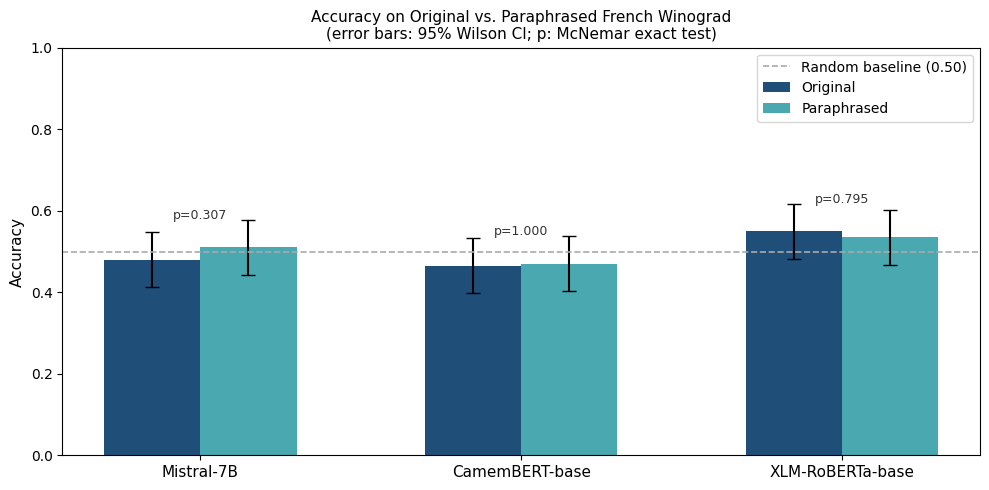

Saved: accuracy_comparison.png


In [23]:
# Figure 1: Accuracy on original vs. paraphrased sentences
# All three models with 95% Wilson CIs and McNemar p-values

orig_accs = [orig_acc_mistral, orig_acc_camembert, orig_acc_xlmr]
para_accs = [para_acc_mistral, para_acc_camembert, para_acc_xlmr]
orig_cis  = [orig_ci_mistral,  orig_ci_camembert,  orig_ci_xlmr]
para_cis  = [para_ci_mistral,  para_ci_camembert,  para_ci_xlmr]
pvals     = [pval_mistral,     pval_camembert,     pval_xlmr]

orig_errs = [[orig_accs[i] - orig_cis[i][0] for i in range(3)],
             [orig_cis[i][1] - orig_accs[i] for i in range(3)]]
para_errs = [[para_accs[i] - para_cis[i][0] for i in range(3)],
             [para_cis[i][1] - para_accs[i] for i in range(3)]]

x     = np.arange(3)
width = 0.30

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, orig_accs, width, label="Original",
       color=DARK_BLUE, yerr=orig_errs, capsize=5, error_kw={"elinewidth": 1.5})
ax.bar(x + width/2, para_accs, width, label="Paraphrased",
       color=TEAL, yerr=para_errs, capsize=5, error_kw={"elinewidth": 1.5})
ax.axhline(0.50, color=BASELINE_COLOR, linestyle="--", linewidth=1.2, label="Random baseline (0.50)")

for i, (xpos, pv) in enumerate(zip(x, pvals)):
    y_top = max(orig_accs[i], para_accs[i]) + 0.07
    ax.text(xpos, y_top, f"p={pv:.3f}{'*' if pv < 0.05 else ''}",
            ha="center", fontsize=9, color="#333333")

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0, 1)
ax.set_title("Accuracy on Original vs. Paraphrased French Winograd\n"
             "(error bars: 95% Wilson CI; p: McNemar exact test)", fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "accuracy_comparison.png"), dpi=300)
plt.show()
print("Saved: accuracy_comparison.png")

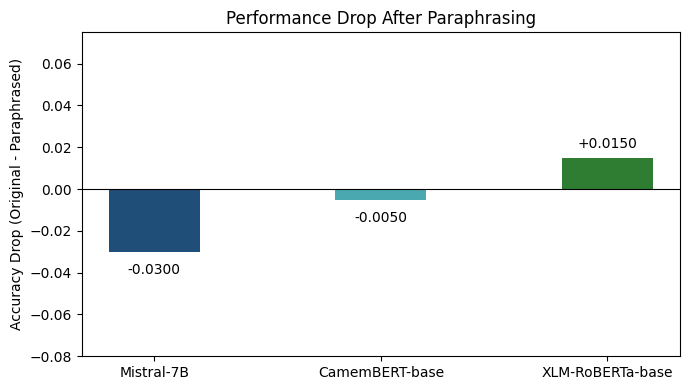

Saved: accuracy_drop.png


In [24]:
# Figure 2: Accuracy drop after paraphrasing for all three models
drops = [orig_acc_mistral - para_acc_mistral,
         orig_acc_camembert - para_acc_camembert,
         orig_acc_xlmr - para_acc_xlmr]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(MODEL_NAMES, drops, color=MODEL_COLORS, width=0.4)

for bar, d in zip(bars, drops):
    ypos = bar.get_height() + 0.003 if d >= 0 else bar.get_height() - 0.012
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{d:+.4f}", ha="center", va="bottom", fontsize=10)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Accuracy Drop (Original - Paraphrased)", fontsize=10)
ax.set_title("Performance Drop After Paraphrasing", fontsize=12)
ax.set_ylim(min(drops) - 0.05, max(drops) + 0.06)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "accuracy_drop.png"), dpi=300)
plt.show()
print("Saved: accuracy_drop.png")

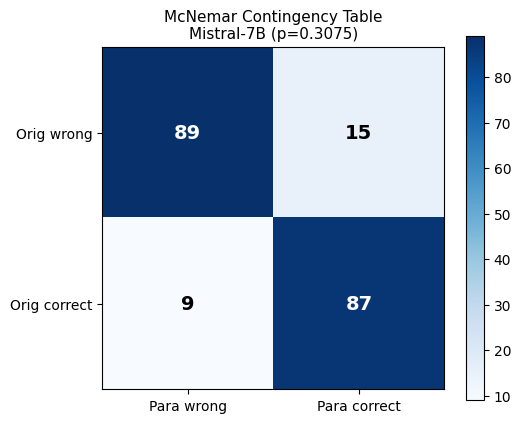

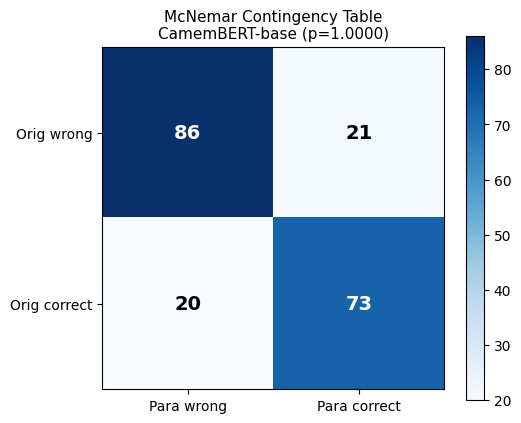

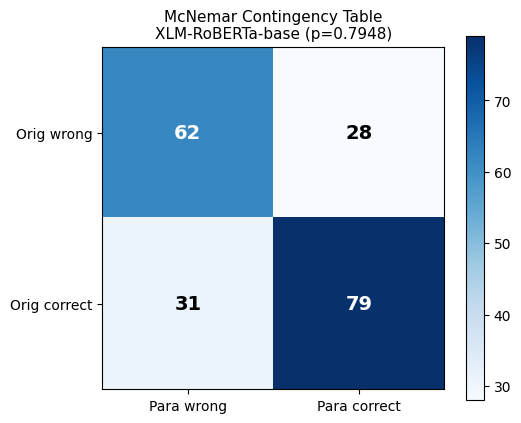

Saved: mcnemar heatmaps for all three models


In [25]:
# Figures 3, 4, 5: McNemar contingency heatmaps for each model

def plot_mcnemar_heatmap(table, model_name, pval, filepath):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(table, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Para wrong", "Para correct"], fontsize=10)
    ax.set_yticklabels(["Orig wrong", "Orig correct"], fontsize=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(table[i, j]),
                    ha="center", va="center", fontsize=14, fontweight="bold",
                    color="white" if table[i, j] > table.max() * 0.6 else "black")
    sig_str = f" (p={pval:.4f}{'*' if pval < 0.05 else ''})"
    ax.set_title(f"McNemar Contingency Table\n{model_name}{sig_str}", fontsize=11)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300)
    plt.show()

plot_mcnemar_heatmap(table_mistral,   "Mistral-7B",       pval_mistral,
                     os.path.join(output_dir, "mcnemar_mistral.png"))
plot_mcnemar_heatmap(table_camembert, "CamemBERT-base",   pval_camembert,
                     os.path.join(output_dir, "mcnemar_camembert.png"))
plot_mcnemar_heatmap(table_xlmr,      "XLM-RoBERTa-base", pval_xlmr,
                     os.path.join(output_dir, "mcnemar_xlmr.png"))
print("Saved: mcnemar heatmaps for all three models")

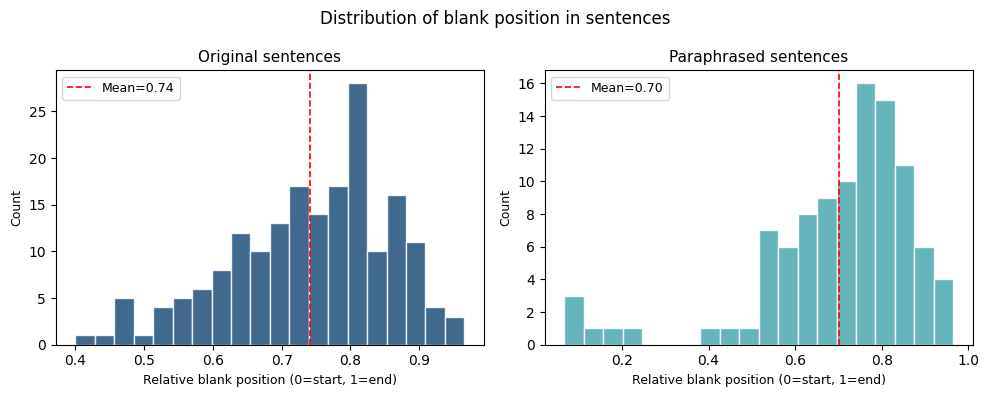

Saved: blank_position_distribution.png


In [26]:
# Figure 6: Blank position distribution
# Verifies that paraphrased sentences have the blank closer to the end

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label, color in zip(
    axes,
    ["orig_blank_pos", "para_blank_pos"],
    ["Original sentences", "Paraphrased sentences"],
    [DARK_BLUE, TEAL]
):
    vals = df[col].dropna()
    ax.hist(vals, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(vals.mean(), color="red", linestyle="--",
               linewidth=1.2, label=f"Mean={vals.mean():.2f}")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Relative blank position (0=start, 1=end)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.legend(fontsize=9)

plt.suptitle("Distribution of blank position in sentences", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "blank_position_distribution.png"), dpi=300)
plt.show()
print("Saved: blank_position_distribution.png")

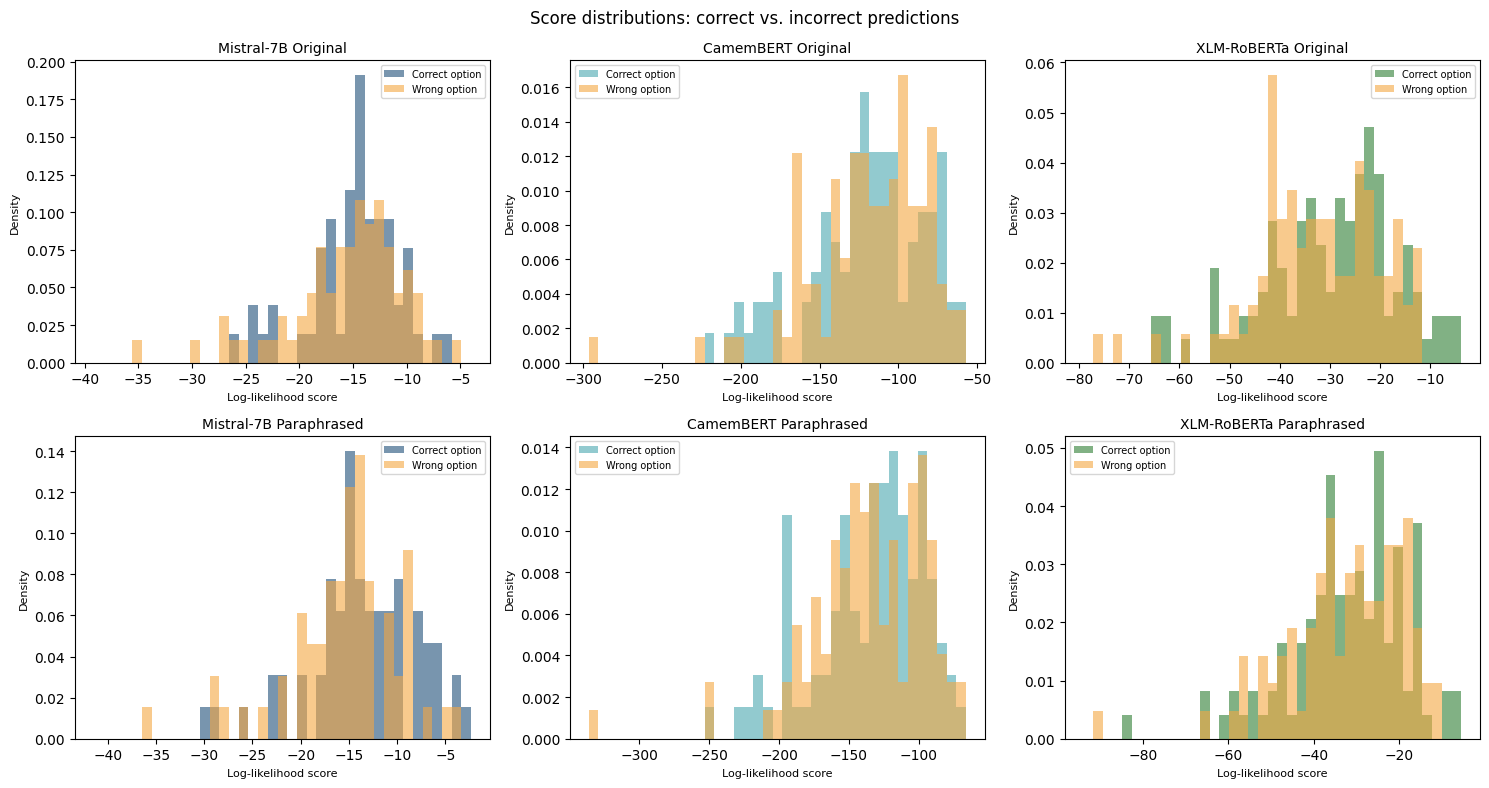

Saved: score_distributions.png


In [27]:
# Figure 7: Log-likelihood score distributions per model and condition
# Shows how scores are distributed for correct vs. incorrect predictions

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

pairs = [
    (orig_results_mistral,   "Mistral-7B Original",        DARK_BLUE),
    (orig_results_camembert, "CamemBERT Original",         TEAL),
    (orig_results_xlmr,      "XLM-RoBERTa Original",       GREEN),
    (para_results_mistral,   "Mistral-7B Paraphrased",     DARK_BLUE),
    (para_results_camembert, "CamemBERT Paraphrased",      TEAL),
    (para_results_xlmr,      "XLM-RoBERTa Paraphrased",   GREEN),
]

for idx, (res, title, color) in enumerate(pairs):
    row = idx // 3
    col = idx % 3
    ax  = axes[row, col]

    s1 = res["score1"].replace([np.inf, -np.inf], np.nan).dropna()
    s2 = res["score2"].replace([np.inf, -np.inf], np.nan).dropna()

    if not s1.empty and not s2.empty:
        all_s = pd.concat([s1, s2])
        bins  = np.linspace(all_s.min(), all_s.max(), 40)
        ax.hist(s1[res["correct"] == 1], bins=bins, color=color,  alpha=0.6, label="Correct option", density=True)
        ax.hist(s2[res["correct"] == 0], bins=bins, color=ORANGE, alpha=0.6, label="Wrong option",   density=True)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Log-likelihood score", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle("Score distributions: correct vs. incorrect predictions", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "score_distributions.png"), dpi=300)
plt.show()
print("Saved: score_distributions.png")

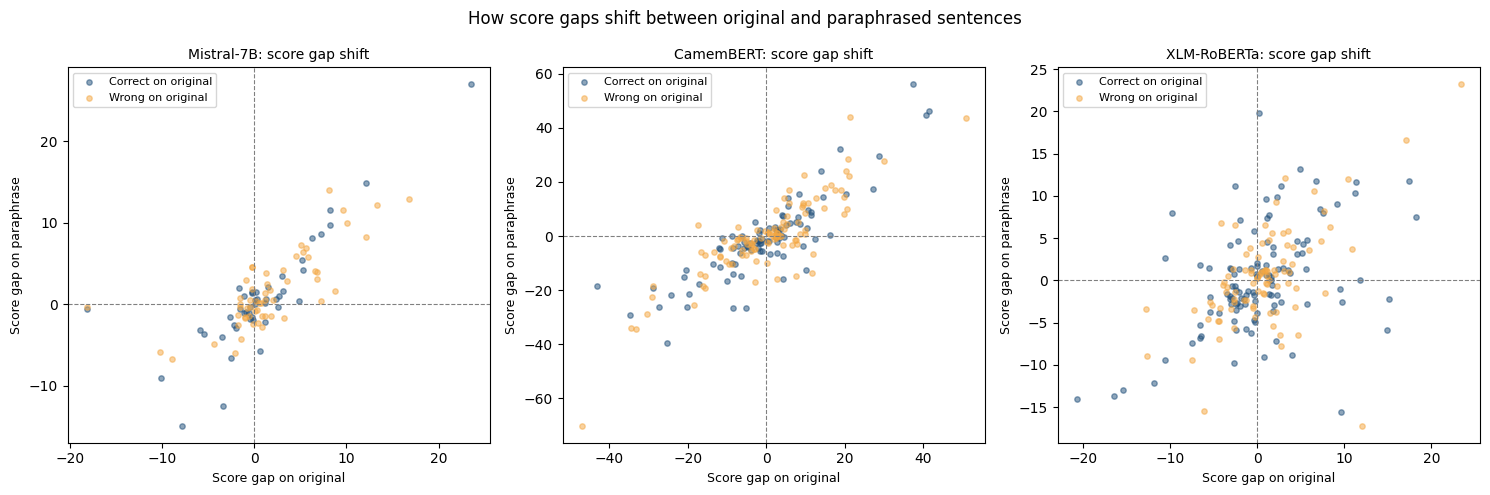

Saved: score_gap_scatter.png


In [28]:
# Figure 8: Score gap scatter plot (score1 - score2) on original vs. paraphrased
# Shows how much the model's preference shifts after paraphrasing

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (res_orig, res_para, label) in zip(axes, [
    (orig_results_mistral,   para_results_mistral,   "Mistral-7B"),
    (orig_results_camembert, para_results_camembert, "CamemBERT"),
    (orig_results_xlmr,      para_results_xlmr,      "XLM-RoBERTa"),
]):
    gap_orig = res_orig["score1"] - res_orig["score2"]
    gap_para = res_para["score1"] - res_para["score2"]
    correct  = res_orig["correct"].values

    ax.scatter(gap_orig[correct == 1], gap_para[correct == 1],
               alpha=0.5, s=15, color=DARK_BLUE, label="Correct on original")
    ax.scatter(gap_orig[correct == 0], gap_para[correct == 0],
               alpha=0.5, s=15, color=ORANGE,    label="Wrong on original")
    ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Score gap on original", fontsize=9)
    ax.set_ylabel("Score gap on paraphrase", fontsize=9)
    ax.set_title(f"{label}: score gap shift", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("How score gaps shift between original and paraphrased sentences", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "score_gap_scatter.png"), dpi=300)
plt.show()
print("Saved: score_gap_scatter.png")

In [29]:
# Save all figures to Google Drive
fig_target = "/content/drive/MyDrive/Thesis_2025/new/figures"
os.makedirs(fig_target, exist_ok=True)

figure_files = [
    "accuracy_comparison.png",
    "accuracy_drop.png",
    "mcnemar_mistral.png",
    "mcnemar_camembert.png",
    "mcnemar_xlmr.png",
    "blank_position_distribution.png",
    "score_distributions.png",
    "score_gap_scatter.png",
]

for fname in figure_files:
    src = os.path.join(output_dir, fname)
    dst = os.path.join(fig_target, fname)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"Saved: {dst}")
    else:
        print(f"[WARNING] Not found: {fname}")

Saved: /content/drive/MyDrive/Thesis_2025/new/figures/accuracy_comparison.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/accuracy_drop.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/mcnemar_mistral.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/mcnemar_camembert.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/mcnemar_xlmr.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/blank_position_distribution.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/score_distributions.png
Saved: /content/drive/MyDrive/Thesis_2025/new/figures/score_gap_scatter.png


## 13. English Sanity Check

This section verifies that the evaluation pipeline produces above-chance results on English before interpreting the French results.
The same Mistral scorer is applied to a random sample of 50 instances from the English WinoWhat dataset.
If accuracy is above chance here, the French chance-level performance is a genuine finding rather than a pipeline bug.
If accuracy is also at chance here, there is likely an implementation error.

Result from our run: Mistral achieved 0.60 on English, confirming the scorer works correctly.

In [30]:
import pandas as pd

# Load the English WinoWhat data
english_path = "/content/drive/MyDrive/Thesis_2025/new/WinoWhat.csv"
df_english   = pd.read_csv(english_path)

print(f"Full English dataset size: {len(df_english)}")
print(f"Columns: {df_english.columns.tolist()}")

# Take a reproducible random sample of 50 instances
random.seed(42)
sample_indices   = random.sample(range(len(df_english)), 50)
df_english_sample = df_english.iloc[sample_indices].copy().reset_index(drop=True)

print(f"Sample size: {len(df_english_sample)}")
print(f"Answer distribution: {df_english_sample['answer'].value_counts().to_dict()}")
print()

# Reload Mistral scorer (free GPU memory first if another model is still loaded)
torch.cuda.empty_cache()
mistral_model_name = "mistralai/Mistral-7B-v0.1"
mistral_scorer     = CausalPartialScorer(mistral_model_name)

print("Running Mistral on English sample...")
eng_acc, eng_results = evaluate_causal(df_english_sample, "sentence", mistral_scorer)
eng_ci = wilson_ci(eng_acc, len(df_english_sample))

print()
print(f"English accuracy : {eng_acc:.4f}  95% CI [{eng_ci[0]:.4f}, {eng_ci[1]:.4f}]")
print(f"Random baseline  : 0.5000")
print()

if eng_acc > 0.55:
    print("RESULT: Scorer works correctly on English.")
    print("        French chance-level performance is a genuine finding.")
else:
    print("RESULT: Scorer also at chance on English.")
    print("        There may still be a bug in the pipeline.")

Full English dataset size: 1177
Columns: ['sentence', 'paraphrased_sentence', 'option1', 'option2', 'answer', 'gpt_category', 'gpt_category_names', 'in_original_experiment']
Sample size: 50
Answer distribution: {2: 32, 1: 18}



Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Running Mistral on English sample...


Causal [sentence]:   0%|          | 0/50 [00:00<?, ?it/s]


English accuracy : 0.6000  95% CI [0.4618, 0.7239]
Random baseline  : 0.5000

RESULT: Scorer works correctly on English.
        French chance-level performance is a genuine finding.


## References

Amsili, P., and Seminck, O. (2017). A Google-proof collection of French Winograd schemas. *Proceedings of the 2nd Workshop on Coreference Resolution Beyond OntoNotes (CORBON 2017)*, 24-29.

Gevers, I., De Marez, V., De Bruyne, L., and Daelemans, W. (2025). WinoWhat: A parallel corpus of paraphrased WinoGrande sentences with common sense categorization. *Proceedings of the 29th Conference on Computational Natural Language Learning (CoNLL 2025)*, 68-80.

Jiang, A. Q., et al. (2023). Mistral 7B. *arXiv preprint arXiv:2310.06825*.

Martin, L., et al. (2020). CamemBERT: A tasty French language model. *Proceedings of ACL 2020*, 7203-7219.

Conneau, A., et al. (2020). Unsupervised cross-lingual representation learning at scale. *Proceedings of ACL 2020*, 8440-8451.

Sakaguchi, K., Le Bras, R., Bhagavatula, C., and Choi, Y. (2021). WinoGrande: An adversarial Winograd schema challenge at scale. *Communications of the ACM*, 64(9), 99-106.

Trinh, T. H., and Le, Q. V. (2018). A simple method for commonsense reasoning. *arXiv preprint arXiv:1806.02847*.

---

## Models

| Model | Type | HuggingFace ID |
|---|---|---|
| Mistral-7B-v0.1 | Causal LM | mistralai/Mistral-7B-v0.1 |
| CamemBERT-base | French Masked LM | camembert/camembert-base |
| XLM-RoBERTa-base | Multilingual Masked LM | xlm-roberta-base |

---

## Dataset

| Source | Instances | Format | Language |
|---|---|---|---|
| Amsili and Seminck (2017) | 100 | XML, converted to fill-in-the-blank | French (original) |
| Gevers et al. (2025), translated | 100 | Fill-in-the-blank | French (via DeepL) |
| **Total** | **200** | | |

---

## Reproducibility

Seeds fixed at the top of the notebook: `random.seed(0)`, `np.random.seed(1234)`, `torch.manual_seed(1234)`, matching Gevers et al. (2025).
All result CSVs and figures are saved to `/content/wino_results` and copied to Google Drive at `Thesis_2025/new/`.